# 04 Estimation, Diagnostics, and Forecasting

By the end of this notebook, you should be able to:

- interpret ARIMA parameter estimates and standard errors;
- explain stationarity and invertibility warnings at a practical level;
- check residuals using plots, residual ACF/PACF, and Ljung-Box tests;
- generate and interpret point forecasts and prediction intervals.

In [1]:
from lite_setup import ensure_packages
await ensure_packages()

Running outside JupyterLite; assuming packages are already installed.


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from checks import check, check_between, check_close, check_columns
from boxjenkins_utils import (
    first_difference, second_difference, seasonal_difference, regular_then_seasonal_difference,
    acf_pacf_table, mean_zero_t_test, fit_arima, fit_sarima, parameter_table,
    forecast_table, ljung_box_table, arima_grid_search, plot_series,
    plot_acf_pacf_pair, plot_forecast,
)
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.precision', 4)
DATA_DIR = Path('data')
towel = pd.read_csv(DATA_DIR / 'paper_towel_sales.csv')
y = towel['Towel_Sales']
ma1 = fit_arima(y, order=(0, 1, 1), trend='n')

## Estimation

Historical software notes mention least squares, conditional sum of squares (CSS), and package-specific defaults. Modern `statsmodels` ARIMA uses likelihood-based estimation by default. Different packages may give slightly different estimates for small samples because they handle starting residuals, likelihood approximations, and optimization differently.

For this course, the important habits are to state the model order, read coefficient signs using the package convention, check whether estimates are meaningful, and check residuals before trusting forecasts.

In [3]:
parameter_table(ma1).round(4)

,estimate,std_error,z_or_t,p_value
ma.L1,0.3518,0.0745,4.7220,0.0
sigma2,1.0708,0.1323,8.0928,0.0


## Stationarity and Invertibility

AR parameters must define a stationary AR component; MA parameters should define an invertible MA component. Packages often enforce or warn about these conditions. If an estimated root is near a boundary, forecasts can be unstable or parameters may be hard to interpret. When warnings appear, simplify the model, revisit differencing, or compare a nearby candidate.

## Boundary Conditions In Plain Math

For AR(1), stationarity requires

$$|\phi_1|<1.$$

For higher-order AR models, the roots of the AR polynomial must lie outside the unit circle. You do not need to compute those roots by hand in routine work, but you do need to understand the warning: near-boundary AR roots mean shocks can persist for a very long time.

For MA(1), invertibility requires the MA effect to be inside the corresponding boundary. With the `statsmodels` sign convention, this is commonly checked as $|\psi_1|<1$ for MA(1). Near-boundary MA parameters make the same autocorrelation pattern representable by nearly equivalent parameter values.

In [4]:
# A quick package-level look at the fitted MA parameter.
psi1 = float(ma1.params.get('ma.L1'))
pd.Series({
    'ma.L1_package_psi': psi1,
    'absolute_value': abs(psi1),
    'inside_simple_MA1_invertibility_boundary': abs(psi1) < 1,
})

ma.L1_package_psi                           0.3518
absolute_value                              0.3518
inside_simple_MA1_invertibility_boundary      True
dtype: object

## Parameter Redundancy and Parsimony

The estimation lecture also warns against overfitting. If a candidate ARIMA model has several insignificant parameters, highly unstable estimates, or warnings about near-boundary roots, the model may be trying to explain the same autocorrelation pattern in too many ways. This is the ARIMA analogue of multicollinearity: parameters can become hard to estimate separately.

Prefer a simpler adequate model over a larger model with slightly better in-sample fit. AIC/BIC are useful, but residual diagnostics and interpretability still matter.

## Residual Diagnostic Goal

A fitted Box-Jenkins model is adequate only if residuals look like white noise:

$$E(e_t) \approx 0,$$

$$\operatorname{Corr}(e_t,e_{t-k}) \approx 0 \quad \text{for meaningful lags } k,$$

and the residual variance does not show a strong changing pattern.

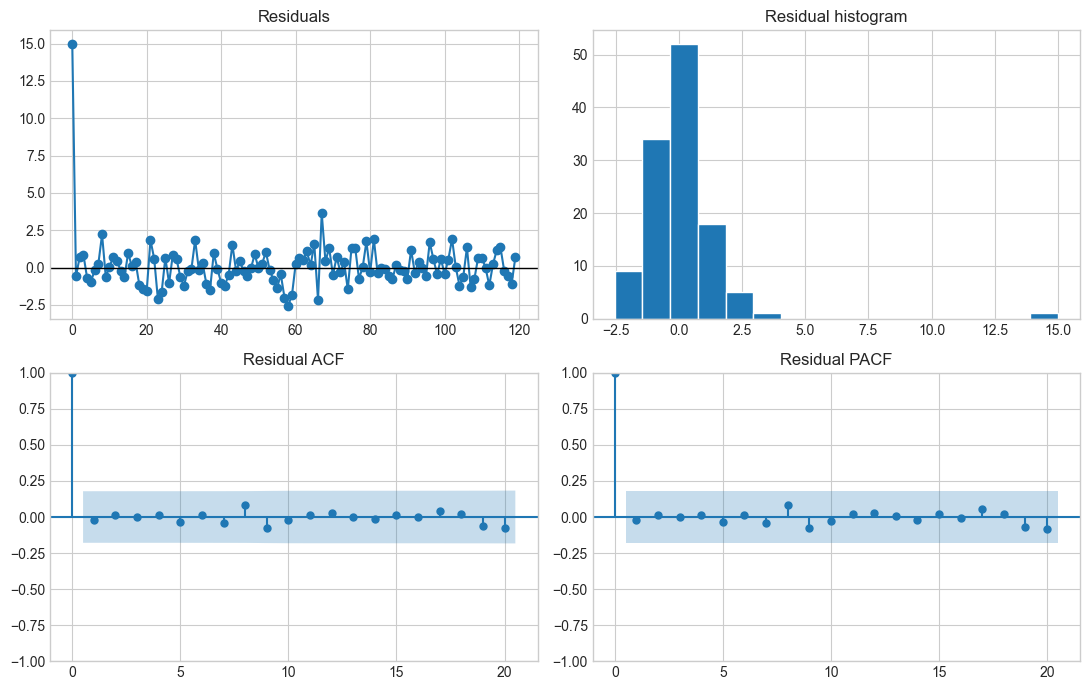

In [5]:
resid = pd.Series(ma1.resid).dropna().reset_index(drop=True)
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
axes[0, 0].plot(resid, marker='o')
axes[0, 0].axhline(0, color='black', linewidth=1)
axes[0, 0].set_title('Residuals')
axes[0, 1].hist(resid, bins=16, edgecolor='white')
axes[0, 1].set_title('Residual histogram')
plot_acf(resid, lags=20, ax=axes[1, 0], title='Residual ACF')
plot_pacf(resid, lags=20, ax=axes[1, 1], title='Residual PACF', method='ywmle')
plt.tight_layout()

In [6]:
ljung_box_table(resid, lags=(6, 12, 18)).round(4)

,lb_stat,lb_pvalue
6,0.2917,0.9995
12,2.4410,0.9984
18,2.8111,1.0000


## Reading The Ljung-Box Test

The Ljung-Box test asks whether a group of residual autocorrelations is collectively zero up to a chosen lag.

- Null hypothesis: residual autocorrelations through that lag are zero.
- Small p-value: residual autocorrelation remains; the model may be inadequate.
- Large p-value: no strong evidence of residual autocorrelation at those lags.

Use several diagnostics together. A model can pass Ljung-Box and still have outliers, changing variance, or an implausible forecast story.

## Forecasts and Prediction Intervals

A point forecast is the conditional expected future value under the fitted model. A prediction interval adds uncertainty from future shocks and parameter/model uncertainty. Intervals usually widen as the horizon grows, especially when the model contains differencing.

In [7]:
fc = forecast_table(ma1, steps=10)
fc.round(4)

,forecast,lower,upper
step,,,
1,15.8873,13.8592,17.9154
2,15.8873,12.4770,19.2976
3,15.8873,11.5116,20.2630
4,15.8873,10.7236,21.0510
5,15.8873,10.0408,21.7337
6,15.8873,9.4299,22.3447
7,15.8873,8.8720,22.9026
8,15.8873,8.3552,23.4193
9,15.8873,7.8718,23.9028


(<Figure size 900x450 with 1 Axes>,
 <Axes: title={'center': 'Towel sales: ARIMA(0,1,1) forecast'}, xlabel='time', ylabel='Towel sales'>)

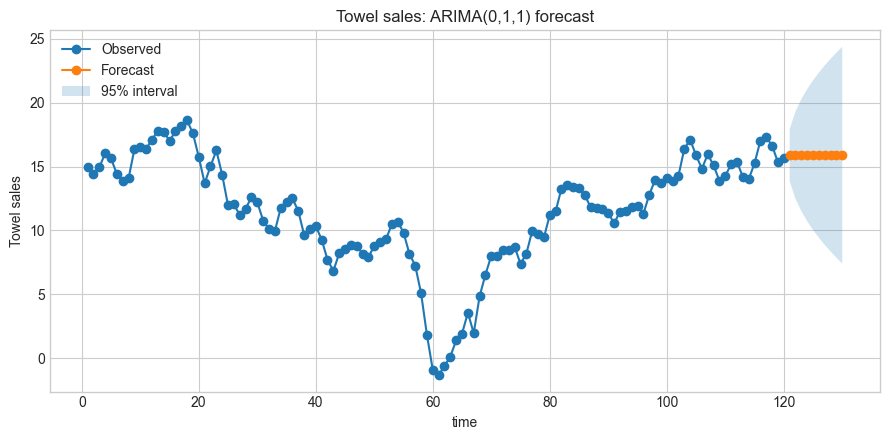

In [8]:
plot_forecast(y, ma1, steps=10, title='Towel sales: ARIMA(0,1,1) forecast', ylabel='Towel sales')

## Model Revision Logic

If diagnostics fail, revise in a targeted way:

- residual ACF has a lag-1 spike: try adding or changing an MA/AR term;
- residual seasonal spikes remain: consider seasonal differencing or seasonal AR/MA terms;
- residual variance changes with level: consider a log or power transformation;
- many insignificant parameters: simplify for parsimony.

The final model is not the most complicated model that can be fitted. It is the simplest adequate model that answers the forecasting question.